# Perceptron

Credits: https://github.com/BecayeSoft/Perceptron/tree/master

### Library import

In [24]:
import pandas as pd
from sklearn.utils import shuffle
import numpy as np
from sklearn.model_selection._split import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

### Read data

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
# Shuffling the data
df = shuffle(df)

df.head()

,0,1,2,3,4
140,6.7,3.1,5.6,2.4,Iris-virginica
100,6.3,3.3,6.0,2.5,Iris-virginica
13,4.3,3.0,1.1,0.1,Iris-setosa
94,5.6,2.7,4.2,1.3,Iris-versicolor
58,6.6,2.9,4.6,1.3,Iris-versicolor


### Variable seperation

In [3]:
X = df.iloc[:, 0:4].values
y = df.iloc[:, 4].values

print(X[0:5])
print(y[0:5])

[[6.7 3.1 5.6 2.4]
 [6.3 3.3 6.  2.5]
 [4.3 3.  1.1 0.1]
 [5.6 2.7 4.2 1.3]
 [6.6 2.9 4.6 1.3]]
['Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor']


### Train-test split

In [6]:
# 75% for train and 25% for test
train_data, test_data, train_labels, test_labels = train_test_split(
                            X, y, test_size=0.25)

# Encoding the labels: 1 for setosa, -1 otherwise
train_labels = np.where(train_labels == 'Iris-setosa', 1, -1)
test_labels = np.where(test_labels == 'Iris-setosa', 1, -1)

print('Train data:', train_data[0:2])
print('Train labels:', train_labels[0:5])

print('Test data:', test_data[0:2])
print('Test labels:', test_labels[0:5])

Train data: [[5.4 3.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]]
Train labels: [ 1 -1  1 -1 -1]
Test data: [[5.4 3.9 1.7 0.4]
 [5.7 2.8 4.5 1.3]]
Test labels: [ 1 -1 -1 -1 -1]


### Perceptron

In [7]:
class Perceptron(object):
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
        Learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.

    Attributes
    -----------
    w_ : 1d-array
        Weights after fitting.
    errors_ : list
        Number of misclassifications (updates) in each epoch.

    """

    def __init__(self, eta=0.01, n_iter=10):
        self.eta = eta
        self.n_iter = n_iter

    # Train the perceptron
    def fit(self, X, y):
        """Fits training data.
        This function take the input of features,
        make predictions, update the weights n_iter times.

        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
            Training vectors, where n_samples is the number of samples and
            n_features is the number of features.
        y : array-like, shape = [n_samples]
            Target values.

        Returns
        -------
        self : object

        """

        # initializing the weights
        self.w_ = np.zeros(1 + X.shape[1])
        self.errors_ = []

        # print("Weights:", self.w_)

        for _ in range(self.n_iter):
            error = 0
            for xi, target in zip(X, y):

                # 1. calculate y^
                y_pred = self.predict(xi)

                # 2. calculate Update
                # update = η * (y - y^)
                update = self.eta * (target - y_pred)

                # 3. Update the weights
                # Wi = Wi + Δ(Wi)       where  Δ(Wi) = update * Xi
                self.w_[1:] = self.w_[1:] + update * xi
                # print(self.w_[1:])

                # Xo = 1 => update * 1 = update
                self.w_[0] = self.w_[0] + update

                # update != 0  ==>  y^ != y  ==>  there is an error
                error += int(update != 0.0)

            self.errors_.append(error)

        return self

    # Weighted Sum
    def net_input(self, X):
        """
        The net_input() function returns the dot product
        i.e. the weighted sum: sum of w*x
        :param: X: an array of features (inputs)
        Returns:
            the dot product of W and X
        """
        # Z = sum (Wi * Xi) where Wo = 0 et Xo = 1
        return np.dot(X, self.w_[1:]) + self.w_[0]

    # Step Function
    def predict(self, X):
        """
        The activation function.
        Returns the predicted value
        :param X: an array of features
        :return:
            y_pred - the predicted value:
                0 if the weighted sum < 0
                1 otherwise
        """
        return np.where(self.net_input(X) >= 0.0, 1, -1)

### Training

In [11]:
perceptron = Perceptron(eta=0.1, n_iter=100)
perceptron.fit(train_data, train_labels)

### Making predictions

In [12]:
test_preds = perceptron.predict(test_data)
print(test_preds)

[ 1 -1 -1 -1 -1 -1 -1  1  1 -1  1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1  1  1
 -1 -1 -1  1  1 -1  1  1 -1 -1 -1  1  1 -1]


In [16]:
accuracy = accuracy_score(test_preds, test_labels)
print('Accuracy:', round(accuracy, 2) * 100, "%")

Accuracy: 100.0 %


### Classification report

In [20]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        14

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



### Confusion matrix

In [22]:
cm = confusion_matrix(test_labels, test_preds)

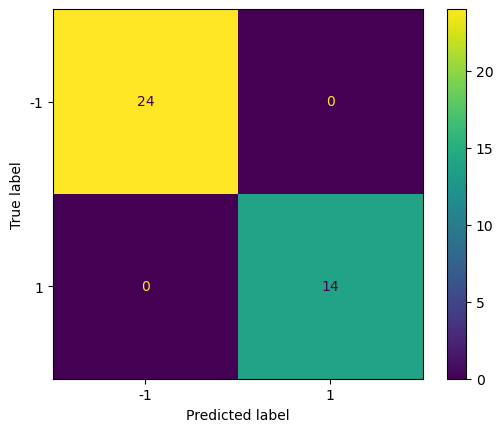

In [26]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [-1, 1])

cm_display.plot()
plt.show()